In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [16]:
# Attempt to load groceries dataset
try:
    raw = pd.read_csv('/content/groceries.csv')
    print('Dataset loaded from /content/groceries.csv')

    if raw.shape[1] == 1:
        transactions = raw.iloc[:, 0].dropna().apply(
            lambda x: [i.strip() for i in str(x).split(',') if i.strip()]
        ).tolist()
    else:
        transactions = raw.apply(
            lambda row: [str(i).strip() for i in row.dropna().tolist() if str(i).strip()],
            axis=1
        ).tolist()

except FileNotFoundError:
    transactions = [
        ['milk', 'bread', 'butter'],
        ['bread', 'eggs'],
        ['milk', 'diapers', 'beer', 'bread'],
        ['bread', 'butter', 'jam']
    ]
    print('Fallback transaction list created')

Fallback transaction list created


In [17]:
print('Total transactions:', len(transactions))
print('First 5 transactions:')

for tx in transactions[:5]:
    print(tx)

Total transactions: 4
First 5 transactions:
['milk', 'bread', 'butter']
['bread', 'eggs']
['milk', 'diapers', 'beer', 'bread']
['bread', 'butter', 'jam']


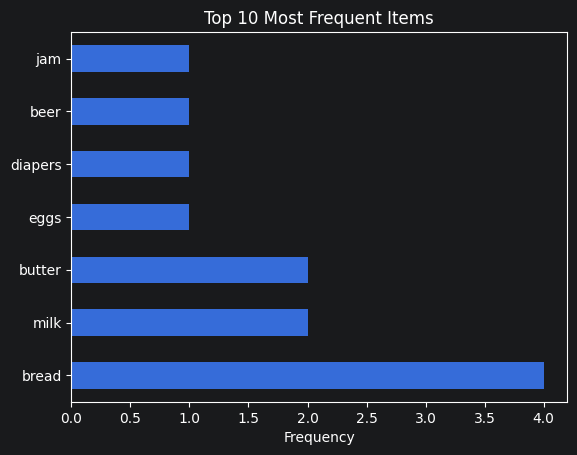

In [18]:
from collections import Counter

# Count item frequencies
item_counts = Counter([item for tx in transactions for item in tx])

# Top 10 frequent items
top_items = pd.Series(item_counts).sort_values(ascending=False).head(10)

top_items.plot(kind='barh')
plt.title('Top 10 Most Frequent Items')
plt.xlabel('Frequency')
plt.show()

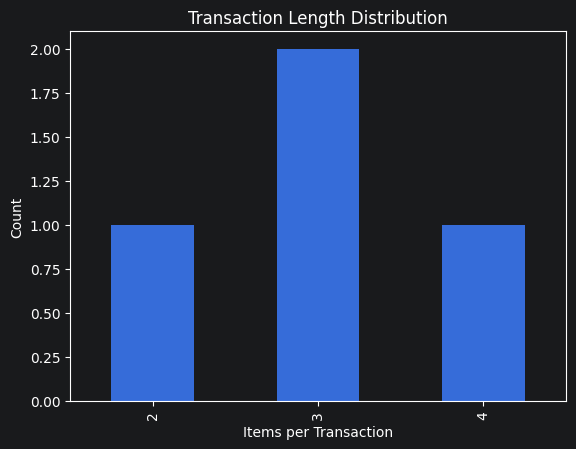

In [19]:
transaction_lengths = [len(tx) for tx in transactions]

pd.Series(transaction_lengths).value_counts().sort_index().plot(kind='bar')
plt.title('Transaction Length Distribution')
plt.xlabel('Items per Transaction')
plt.ylabel('Count')
plt.show()

In [20]:
cleaned_transactions = []

for tx in transactions:
    cleaned = [str(item).strip().lower() for item in tx if str(item).strip()]
    cleaned_transactions.append(cleaned)

transactions = cleaned_transactions
print('Transactions cleaned successfully.')

Transactions cleaned successfully.


In [21]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)
print(basket.head())

    beer  bread  butter  diapers   eggs    jam   milk
0  False   True    True    False  False  False   True
1  False   True   False    False   True  False  False
2   True   True   False     True  False  False   True
3  False   True    True    False  False   True  False


In [22]:
min_support = 0.15
print('Minimum support selected:', min_support)

Minimum support selected: 0.15


In [23]:
frequent_itemsets = apriori(
    basket,
    min_support=min_support,
    use_colnames=True
)

print(
    frequent_itemsets
    .sort_values('support', ascending=False)
    .head(10)
)

    support                           itemsets
1      1.00                 frozenset({bread})
2      0.50                frozenset({butter})
6      0.50                  frozenset({milk})
10     0.50         frozenset({bread, butter})
14     0.50           frozenset({bread, milk})
0      0.25                  frozenset({beer})
15     0.25           frozenset({jam, butter})
23     0.25  frozenset({diapers, bread, milk})
22     0.25   frozenset({bread, milk, butter})
21     0.25    frozenset({bread, jam, butter})


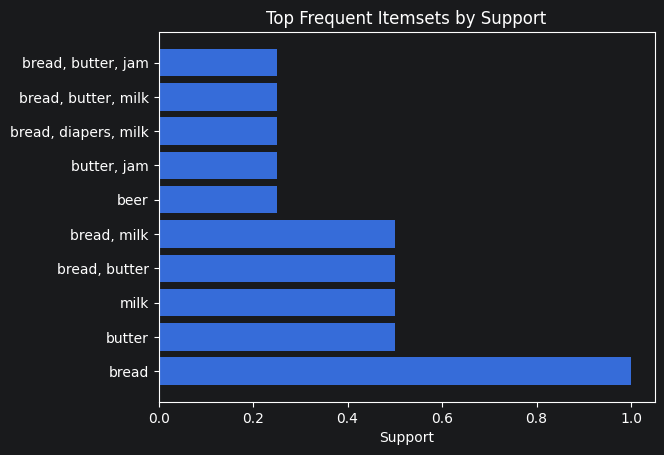

In [24]:
top_support = (
    frequent_itemsets
    .sort_values('support', ascending=False)
    .head(10)
    .copy()
)

top_support['itemset'] = top_support['itemsets'].apply(
    lambda s: ', '.join(sorted(list(s)))
)

plt.barh(top_support['itemset'], top_support['support'])
plt.title('Top Frequent Itemsets by Support')
plt.xlabel('Support')
plt.show()

In [25]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)

rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print(
    rules
    .sort_values('lift', ascending=False)
    .head(10)
)

                          antecedents                        consequents  \
31                  frozenset({beer})         frozenset({diapers, milk})   
18           frozenset({beer, bread})               frozenset({diapers})   
59                  frozenset({beer})  frozenset({diapers, bread, milk})   
58         frozenset({diapers, milk})           frozenset({beer, bread})   
57        frozenset({diapers, bread})            frozenset({beer, milk})   
54            frozenset({beer, milk})        frozenset({diapers, bread})   
53           frozenset({beer, bread})         frozenset({diapers, milk})   
52  frozenset({diapers, bread, milk})                  frozenset({beer})   
49     frozenset({beer, bread, milk})               frozenset({diapers})   
33               frozenset({diapers})            frozenset({beer, milk})   

    support  confidence  lift  
31     0.25         1.0   4.0  
18     0.25         1.0   4.0  
59     0.25         1.0   4.0  
58     0.25         1.0   4.0  
57 

E:\My Python Projects\ml_env\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


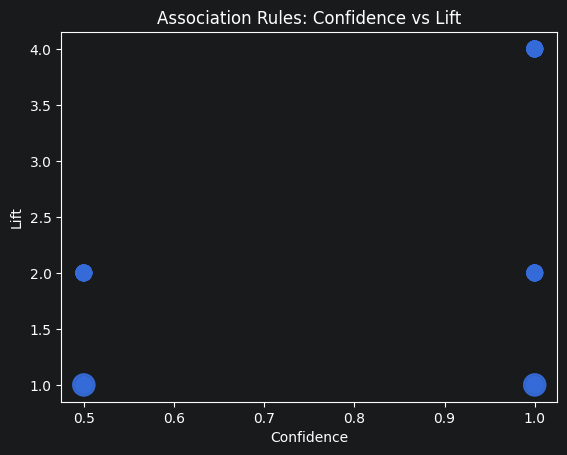

In [26]:
plt.scatter(
    rules['confidence'],
    rules['lift'],
    s=rules['support'] * 500,
    alpha=0.7
)

plt.title('Association Rules: Confidence vs Lift')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.show()